## 0. Instalação de dependências

In [8]:
# Execute apenas na primeira vez ou ao atualizar o ambiente.
!pip install -U openml pandas scikit-learn joblib seaborn matplotlib pymfe pygad -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.1/156.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 79.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that 

## 1. Imports e configuração global

In [1]:
# ── Biblioteca padrão ──────────────────────────────────────────────────────
import os           # variáveis de ambiente e contagem de CPUs
import re           # expressões regulares para normalização de nomes
import json         # serialização legível de objetos simples
import random       # semente global de aleatoriedade
import pickle       # serialização binária de objetos Python complexos
import warnings     # supressão de avisos irrelevantes
from pathlib import Path           # manipulação portável de caminhos
from collections import Counter    # contagem de frequência das meta-features selecionadas
from dataclasses import dataclass  # estrutura de dados sem boilerplate
from typing import Dict, List, Optional, Tuple

# ── Computação numérica e dados ────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── OpenML, meta-features e GA ─────────────────────────────────────────────
import openml
import pygad
from pymfe.mfe import MFE

# ── Scikit-learn ───────────────────────────────────────────────────────────
from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier,  # substitui GradientBoostingClassifier
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Semente única para todas as fontes de aleatoriedade do experimento.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

TARGET_DATASETS   = 500
OPENML_SAMPLE_CAP = 650

# N_JOBS: paralelismo externo por dataset; internamente cada modelo usa n_jobs=1
# para evitar oversubscription (mais threads que CPUs físicos).
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

# ── Diretórios de artefatos ────────────────────────────────────────────────
PROJECT_ROOT            = Path.cwd()
CACHE_DIR               = PROJECT_ROOT / "artifacts_meta_learning"
DATASETS_DIR            = CACHE_DIR / "datasets"
META_DIR                = CACHE_DIR / "meta"
RESULTS_DIR             = CACHE_DIR / "results"
INTERMEDIATE_TABLES_DIR = PROJECT_ROOT / "intermediate_tables_csv"

for folder in [CACHE_DIR, DATASETS_DIR, META_DIR, RESULTS_DIR, INTERMEDIATE_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MPL_TMP = os.path.join(os.getcwd(), ".mplconfig")
os.makedirs(MPL_TMP, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPL_TMP)

print(f"N_JOBS configurado para: {N_JOBS}")
print(f"Cache local: {CACHE_DIR}")


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


N_JOBS configurado para: 7
Cache local: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning


## 2. Configurações experimentais

In [ ]:
# ── Algoritmos do nível-base ───────────────────────────────────────────────
# Cada algoritmo é avaliado em todos os datasets via cross-validation.
# O algoritmo com maior acurácia média vira a meta-label daquele dataset.
BASE_MODELS = {
    "DecisionTree":         DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVC":                  SVC(gamma="scale", random_state=RANDOM_STATE),
    "KNN":                  KNeighborsClassifier(),
    "LogisticRegression":   LogisticRegression(
                                max_iter=1500, solver="lbfgs",
                                random_state=RANDOM_STATE),
    "ExtraTrees":           ExtraTreesClassifier(
                                n_estimators=100,
                                random_state=RANDOM_STATE,
                                n_jobs=1),
    "HistGradientBoosting": HistGradientBoostingClassifier(
                                random_state=RANDOM_STATE),
    "GaussianNB":           GaussianNB(),
}

# ── Meta-modelo completo — avaliação final ────────────────────────────────
# Usado em evaluate_meta_strategy, get_topk_importance_mask e baselines.
# Alta quantidade de estimadores para máxima qualidade nos resultados reportados.
META_MODEL = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# ── Meta-modelo leve — usado APENAS dentro do fitness do GA ───────────────
# O GA só precisa comparar máscaras entre si, não maximizar acurácia absoluta.
# Menos estimadores e folds são suficientes para discriminar boas seleções,
# reduzindo o tempo total do GA sem impacto expressivo nos resultados finais.
GA_INTERNAL_MODEL = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# ── Esquemas de cross-validation ───────────────────────────────────────────
# OUTER_CV: StratifiedKFold garante proporção de classes preservada em todos
# os folds, crucial para meta-datasets desbalanceados.
OUTER_CV = StratifiedKFold(n_splits=8, shuffle=True, random_state=RANDOM_STATE)

# INNER_META_CV: usado dentro do fitness do GA — balanceia sinal de qualidade
# e velocidade de avaliação.
INNER_META_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# BASE_CV: avalia cada base learner em cada dataset do OpenML.
BASE_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Configuração do Algoritmo Genético ────────────────────────────────────
GA_CONFIG = {
    "num_generations":       40,
    "sol_per_pop":           30,
    "num_parents_mating":    10,
    "parent_selection_type": "sss",
    "keep_elitism":          3,
    "crossover_type":        "two_points",
    "mutation_type":         "adaptive",
    "mutation_probability":  [0.25, 0.05],
    "gene_space":            [0, 1],
    "suppress_warnings":     True,
    "stop_criteria":         ["saturate_12"],
}

# ── Penalidade dinâmica do fitness do GA ──────────────────────────────────
GA_PENALTY_ALPHA     = 0.08   # controla a intensidade geral da penalidade
GA_PENALTY_THRESHOLD = 0.40   # fração de features acima da qual a penalidade se torna quadrática

META_FEATURE_GROUPS   = ["general", "statistical", "info-theory", "landmarking", "complexity", "model-based", "concept", "clustering", "itemset", "relative"]
CORRELATION_THRESHOLD = 0.90


## 3. Utilitários de cache em disco

Cada etapa pesada persiste seus artefatos como arquivos `.pkl`. Nas execuções
seguintes o notebook detecta os arquivos e pula o processamento já concluído.


In [3]:
def save_pickle(obj, path: Path) -> None:
    """Persiste qualquer objeto Python em formato binário (pickle)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as f:
        pickle.dump(obj, f)

def load_pickle(path: Path):
    """Carrega um objeto previamente serializado com save_pickle."""
    with path.open("rb") as f:
        return pickle.load(f)

def save_json(obj, path: Path) -> None:
    """Persiste listas/dicionários simples em JSON legível por humanos."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path: Path):
    """Carrega um objeto previamente salvo com save_json."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Persiste um DataFrame preservando índices, dtypes e metadados."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(path)

def load_dataframe(path: Path) -> pd.DataFrame:
    """Carrega um DataFrame previamente salvo com save_dataframe."""
    return pd.read_pickle(path)

# ── Caminhos dos artefatos (numerados para rastreabilidade) ────────────────
CATALOG_PATH              = CACHE_DIR / "01_openml_catalog_filtered_and_deduplicated.pkl"
DATASETS_PATH             = DATASETS_DIR / "02_real_openml_datasets_downloaded_and_validated.pkl"
BASE_RESULTS_PATH         = META_DIR / "03_base_level_model_evaluation_results.pkl"
BASE_RESULTS_DF_PATH      = META_DIR / "03_base_level_model_evaluation_results_dataframe.pkl"
META_Y_PATH               = META_DIR / "04_meta_labels_best_base_learner_per_dataset.pkl"
META_X_PATH               = META_DIR / "05_meta_features_matrix_extracted_with_pymfe.pkl"
OUTER_RESULTS_PATH        = RESULTS_DIR / "06_outer_cv_ga_feature_selection_evaluation_results.pkl"
TOP_FEATURES_COUNTER_PATH = RESULTS_DIR / "07_ga_selected_meta_feature_frequency_counter.pkl"
ALL_FOLDS_HISTORY_PATH    = RESULTS_DIR / "08_ga_convergence_history_all_folds.pkl"


## 4. Seleção de datasets no OpenML

Busca e filtra datasets de classificação que satisfaçam critérios controlados
de tamanho, dimensão e balanceamento de classes.


In [ ]:
def normalize_name(name: object) -> str:
    """
    Normaliza o nome de um dataset para identificar duplicatas semânticas.

    Remove sufixos de versão ('_v2', '-v3'), substitui separadores por '_'
    e converte para minúsculas. Exemplos: 'Iris_v2' e 'iris-V3' → 'iris'.
    Usado para deduplicar o catálogo mantendo apenas a versão mais recente
    de cada dataset.
    """
    if pd.isna(name):
        return "unknown"
    name = str(name).lower()
    name = re.sub(r"[_\- ]v\d+", "", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


def build_openml_catalog(target_size: int, sample_cap: int, seed: int) -> pd.DataFrame:
    """
    Constrói um catálogo filtrado de datasets candidatos do OpenML.

    Filtros de qualidade aplicados (eliminam datasets inviáveis ou problemáticos):
      • instâncias dentro de um intervalo controlado  — tamanho computacionalmente viável
      • features dentro de um intervalo moderado      — complexidade compatível com pymfe
      • número de classes dentro de um intervalo      — classificação multiclasse controlada
      • classe minoritária com mínimo de instâncias   — permite StratifiedKFold sem erros
      • exclui datasets FOREX                         — séries temporais, incompatíveis com pymfe

    Deduplicação semântica: mantém apenas a versão mais recente de cada
    nome normalizado (evita múltiplas versões do mesmo problema no meta-dataset).
    """
    print("Carregando catálogo do OpenML...")
    df = openml.datasets.list_datasets(output_format="dataframe")

    required_cols = [
        "did", "name", "version",
        "NumberOfInstances", "NumberOfFeatures",
        "NumberOfClasses", "MinorityClassSize",
    ]
    df = df[required_cols].copy()

    df = df[
        df["NumberOfInstances"].between(200, 10000)
        & df["NumberOfFeatures"].between(5, 100)
        & df["NumberOfClasses"].between(2, 10)
        & (df["MinorityClassSize"] >= 20)
        & (~df["name"].str.contains("FOREX", case=False, na=False))
    ].copy()

    df["normalized_name"] = df["name"].apply(normalize_name)
    df = df.drop_duplicates(subset=["did"])
    df = df.sort_values("version", ascending=False).drop_duplicates(
        subset=["normalized_name"]
    )

    if len(df) > sample_cap:
        df = df.sample(n=sample_cap, random_state=seed)

    # Embaralha sem ordenar por tamanho — garante diversidade de datasets.
    return df.sample(frac=1, random_state=seed + 1).reset_index(drop=True)


if CATALOG_PATH.exists():
    catalog_df = load_dataframe(CATALOG_PATH)
    print(f"Catálogo carregado do cache: {CATALOG_PATH}")
else:
    catalog_df = build_openml_catalog(TARGET_DATASETS, OPENML_SAMPLE_CAP, RANDOM_STATE)
    save_dataframe(catalog_df, CATALOG_PATH)
    print(f"Catálogo salvo em: {CATALOG_PATH}")

print(f"Candidatos no catálogo: {len(catalog_df)}")
catalog_df.head()


Catálogo carregado do cache: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/01_openml_catalog_filtered_and_deduplicated.pkl
Candidatos no catálogo: 650


,did,name,version,NumberOfInstances,NumberOfFeatures,NumberOfClasses,MinorityClassSize,normalized_name
0,446,prnn_crabs,1,200.0,8.0,2.0,100.0,prnn_crabs
1,721,pwLinear,2,200.0,11.0,2.0,97.0,pwlinear
2,43786,Zombies-Apocalypse,1,200.0,13.0,2.0,79.0,zombies_apocalypse
3,46844,Predicting_Risk_Factors_of_Chronic_Kidney_Disease,2,200.0,29.0,2.0,72.0,predicting_risk_factors_of_chronic_kidney_disease
4,42172,regime_alimentaire,1,202.0,20.0,2.0,41.0,regime_alimentaire


## 5. Download e validação dos datasets

Cada dataset é baixado individualmente do OpenML, sanitizado e validado.
Datasets que falham em qualquer critério são descartados silenciosamente
para não interromper o pipeline.


In [5]:
def _coerce_target(y: object) -> pd.Series:
    """
    Normaliza o target para pd.Series unidimensional com índice resetado.

    O OpenML retorna targets como Series, DataFrame ou array dependendo
    do dataset. Esta função unifica todos os casos e rejeita targets
    multi-rótulo (múltiplas colunas), que este experimento não suporta.
    """
    if isinstance(y, pd.Series):
        return y.reset_index(drop=True)
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("Target multirrótulo não suportado.")
        return y.iloc[:, 0].reset_index(drop=True)
    return pd.Series(y).reset_index(drop=True)


def _sanitize_dataframe(X: object) -> pd.DataFrame:
    """
    Padroniza o DataFrame de features com colunas nomeadas como strings.

    Alguns datasets retornam arrays numpy ou DataFrames com índices inteiros.
    Converter para strings garante compatibilidade com ColumnTransformer e pymfe.
    """
    df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    df.columns = [str(col) for col in df.columns]
    return df.reset_index(drop=True)


def download_openml_dataset(row: pd.Series) -> Optional[Dict]:
    """
    Baixa, valida e padroniza um único dataset do OpenML.

    Validações após o download (reconfirma após limpeza do target):
      • len(X) == len(y): consistência entre features e labels
      • 200 ≤ instâncias ≤ 10.000: tamanho ainda dentro do range
      • 5 ≤ features ≤ 100: dimensão dentro do range
      • 2 ≤ classes únicas ≤ 10: problema de classificação válido
      • classe minoritária ≥ 20: StratifiedKFold possível

    Retorna None em qualquer falha (download, conversão ou validação).
    """
    did = int(row["did"])
    try:
        dataset = openml.datasets.get_dataset(did, download_data=True)
        X, y, _, _ = dataset.get_data(
            dataset_format="dataframe",
            target=dataset.default_target_attribute,
        )
    except Exception as exc:
        print(f"[skip] did={did} | erro no download: {exc}")
        return None

    try:
        X = _sanitize_dataframe(X)
        y = _coerce_target(y)
    except Exception as exc:
        print(f"[skip] did={did} | erro na conversão: {exc}")
        return None

    if len(X) != len(y):
        return None
    if not (200 <= X.shape[0] <= 10000) or not (5 <= X.shape[1] <= 100):
        return None

    # Remove linhas com target inválido e revalida as condições de balanceamento.
    y = y.replace([np.inf, -np.inf], np.nan)
    valid_mask = y.notna()
    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    if y.nunique() < 2 or y.nunique() > 10:
        return None
    if y.value_counts().min() < 20:
        return None

    return {
        "openml_id": did,
        "name": f"openml_{did}_{normalize_name(row['name'])}",
        "data": X,
        "target": y,
    }


if DATASETS_PATH.exists():
    datasets = load_pickle(DATASETS_PATH)
    print(f"Datasets carregados do cache: {DATASETS_PATH}")
else:
    datasets = []
    for _, row in catalog_df.iterrows():
        ds = download_openml_dataset(row)
        if ds is not None:
            datasets.append(ds)
        if len(datasets) >= TARGET_DATASETS:
            break
    save_pickle(datasets, DATASETS_PATH)
    print(f"Datasets salvos em: {DATASETS_PATH}")

print(f"Datasets válidos: {len(datasets)}")
datasets[0]["data"].head() if datasets else None


[skip] did=40589 | erro no download: Number of requested targets 6 is not implemented.
Datasets salvos em: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/datasets/02_real_openml_datasets_downloaded_and_validated.pkl
Datasets válidos: 500


,sex,index,FL,RW,CL,CW,BD
0,Male,1,8.1,6.7,16.1,19.0,7.0
1,Male,2,8.8,7.7,18.1,20.8,7.4
2,Male,3,9.2,7.8,19.0,22.4,7.7
3,Male,4,9.6,7.9,20.1,23.1,8.2
4,Male,5,9.8,8.0,20.3,23.0,8.2


## 6. Funções auxiliares de pré-processamento

In [ ]:
def infer_column_types(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    Identifica colunas categóricas e numéricas pelo dtype do pandas.

    Categóricas (precisam de encoding): object, category, bool.
    Numéricas (passam direto): float, int e derivados.
    """
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    numeric_cols = [c for c in df.columns if c not in categorical_cols]
    return categorical_cols, numeric_cols


def encode_target(y: pd.Series) -> np.ndarray:
    """
    Codifica o target em inteiros contíguos [0, n_classes-1].

    Converter para str antes garante compatibilidade quando o OpenML
    retorna tipos mistos (int, float, str) na mesma coluna categórica.
    """
    return LabelEncoder().fit_transform(
        pd.Series(y).astype(str).reset_index(drop=True)
    )


def build_base_pipeline(model) -> Pipeline:
    """
    Constrói o pipeline de pré-processamento para avaliação dos base learners.

    Numéricos:    imputa pela mediana (robusto a outliers, muito mais rápido)
    Categóricos:  imputa pela moda + one-hot encoding
    Desconhecidas: descartadas (remainder='drop')
    """
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # era KNNImputer
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer,
             lambda X: X.select_dtypes(exclude=["object","category","bool"]).columns),
            ("cat", categorical_transformer,
             lambda X: X.select_dtypes(include=["object","category","bool"]).columns),
        ],
        remainder="drop",
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def prepare_dataset_for_mfe(df: pd.DataFrame) -> np.ndarray:
    """
    Converte o dataset para matriz numérica densa compatível com o pymfe.

    O MFE exige numpy array sem NaN e sem colunas categóricas cruas.

    Processo:
      1. Categóricos: imputa pela moda → OrdinalEncoder
         (preserva estrutura ordinal para métricas de correlação do MFE)
      2. Numéricos: converte para float explicitamente
      3. KNNImputer (n_neighbors=5): preenche NaNs restantes via vizinhos próximos.
         Aqui KNNImputer É justificado — ao contrário do nível-base, a qualidade
         das meta-features depende de uma imputação mais rica: métricas como
         correlação e entropia são sensíveis à distribuição dos dados preenchidos.
    """
    categorical_cols, numeric_cols = infer_column_types(df)
    work_df = df.copy()

    if categorical_cols:
        work_df[categorical_cols] = SimpleImputer(
            strategy="most_frequent"
        ).fit_transform(work_df[categorical_cols])
        work_df[categorical_cols] = OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ).fit_transform(work_df[categorical_cols])

    if numeric_cols:
        work_df[numeric_cols] = work_df[numeric_cols].apply(
            pd.to_numeric, errors="coerce"
        )

    return np.asarray(
        KNNImputer(n_neighbors=5).fit_transform(work_df), dtype=float
    )


## 7. Fase 1 — Geração das meta-labels (`meta_y`)

Avalia todos os base learners em cada dataset e registra o mais acurado.
Esse nome (ex: 'HistGradientBoosting') vira a meta-label do dataset.


In [7]:
def evaluate_base_learners(dataset: Dict) -> Dict:
    """
    Avalia todos os algoritmos candidatos em um dataset e retorna o melhor.

    Para cada algoritmo em BASE_MODELS:
      1. Constrói o pipeline com pré-processamento (build_base_pipeline)
      2. Executa cross_val_score com BASE_CV (StratifiedKFold 5-fold)
      3. Registra a acurácia média como score neste dataset

    O algoritmo com maior acurácia média vira a meta-label do dataset.

    n_jobs=1: o paralelismo externo (Parallel por dataset) já distribui
    a carga entre os CPUs. Usar n_jobs>1 internamente causaria
    oversubscription (mais threads que CPUs físicos), degradando performance.
    """
    X = dataset["data"]
    y = encode_target(dataset["target"])

    scores = {}
    for name, model in BASE_MODELS.items():
        cv_scores = cross_val_score(
            build_base_pipeline(clone(model)), X, y,
            cv=BASE_CV, scoring="accuracy", n_jobs=1,
        )
        scores[name] = float(np.mean(cv_scores))

    best = max(scores, key=scores.get)
    return {"dataset_name": dataset["name"], "best_model": best, "scores": scores}


if (BASE_RESULTS_PATH.exists()
        and BASE_RESULTS_DF_PATH.exists()
        and META_Y_PATH.exists()):
    print("Base-level results encontrados no cache, carregando...")
    base_results    = load_pickle(BASE_RESULTS_PATH)
    base_results_df = load_dataframe(BASE_RESULTS_DF_PATH)
    meta_y          = np.array(load_pickle(META_Y_PATH))
    print(f"Carregados de: {BASE_RESULTS_PATH}")
else:
    print("Avaliando base learners nos datasets (pode demorar)...")
    base_results = Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(evaluate_base_learners)(ds) for ds in datasets
    )
    meta_y = np.array([r["best_model"] for r in base_results])
    base_results_df = pd.DataFrame([
        {"dataset_name": r["dataset_name"], **r["scores"], "meta_label": r["best_model"]}
        for r in base_results
    ])
    save_pickle(base_results, BASE_RESULTS_PATH)
    save_dataframe(base_results_df, BASE_RESULTS_DF_PATH)
    save_pickle(meta_y.tolist(), META_Y_PATH)
    print(f"Resultados salvos em: {BASE_RESULTS_PATH}")

print("\nDistribuição das meta-labels:")
print(pd.Series(meta_y).value_counts())
base_results_df.head()


Base-level results encontrados no cache, carregando...
Carregados de: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/03_base_level_model_evaluation_results.pkl

Distribuição das meta-labels:
HistGradientBoosting    202
ExtraTrees              135
LogisticRegression       80
SVC                      56
DecisionTree             20
GaussianNB                4
KNN                       3
Name: count, dtype: int64


,dataset_name,DecisionTree,SVC,KNN,LogisticRegression,ExtraTrees,HistGradientBoosting,GaussianNB,meta_label
0,openml_446_prnn_crabs,0.91500,0.83500,0.93000,0.995000,0.955000,0.935000,0.625000,LogisticRegression
1,openml_721_pwlinear,0.81000,0.88500,0.83000,0.845000,0.890000,0.900000,0.845000,HistGradientBoosting
2,openml_43786_zombies_apocalypse,0.69000,0.70000,0.67500,0.870000,0.825000,0.825000,0.820000,LogisticRegression
3,openml_46844_predicting_risk_factors_of_chroni...,1.00000,1.00000,0.96000,1.000000,1.000000,1.000000,1.000000,DecisionTree
4,openml_42172_regime_alimentaire,0.92061,0.94061,0.94061,0.980122,0.876098,0.955366,0.456585,LogisticRegression


## 8. Fase 2 — Extração das meta-features (`meta_X`)

O pymfe calcula métricas descritivas de cada dataset em 4 grupos.
Para métricas que retornam uma distribuição (ex: correlações de todos
os pares de atributos), calculamos 4 resumos: mean, sd, min, max —
multiplicando a riqueza descritiva do meta-dataset.


In [8]:
def extract_meta_features(dataset: Dict, groups: List[str]) -> Dict:
    """
    Extrai meta-features de um dataset usando o pymfe (MFE).

    Grupos e o que cada um captura:
      general:     estrutura básica — n_features, n_instances, n_classes,
                   razão instâncias/features, proporção de categóricos, etc.
      statistical: momentos estatísticos e correlações entre atributos
                   numéricos (média, variância, curtose, assimetria, etc.)
      info-theory: entropia das classes, informação mútua atributo-classe,
                   joint entropy — descrevem a estrutura de informação do dataset
      landmarking: acurácia de classificadores simples (1-NN, árvore rasa,
                   Naive Bayes) como proxies rápidas de complexidade do problema
      complexity:  métricas de complexidade de fronteira de decisão — sobreposição
                   de classes, geometria do espaço de features e separabilidade linear
      model-based: meta-features extraídas de árvores de decisão (profundidade,
                   nº de folhas, forma da árvore) como proxy de complexidade estrutural
      concept:     caracterização do conceito-alvo via entropia de vizinhança e
                   coeficiente de variação — quantifica a coerência local das classes
      clustering:  qualidade de agrupamentos não-supervisionados (silhouette,
                   coeficiente de Dunn) como proxy da estrutura natural dos dados
      itemset:     suporte e confiança de itemsets frequentes — captura
                   co-ocorrências e dependências entre atributos

    Resumos (mean, sd, min, max, kurtosis, iq_range, histogram): meta-features
    que retornam uma distribuição de valores são sumarizadas em 7 estatísticas,
    aumentando a riqueza descritiva do meta-dataset sem perder informação.

    Retorna dicionário com nomes e valores das meta-features extraídas.
    """
    X_num = prepare_dataset_for_mfe(dataset["data"])
    y     = encode_target(dataset["target"])

    mfe = MFE(groups=groups, summary=["mean", "sd", "min", "max", "median", "quantiles", "kurtosis", "iq_range", "histogram"])
    mfe.fit(X_num, y)
    names, values = mfe.extract()

    return {
        "dataset_name":   dataset["name"],
        "feature_names":  list(names),
        "feature_values": list(values),
    }



In [9]:
import sys
from datetime import datetime as _dt

# ── Logger: escreve no terminal e acumula para o .txt ─────────────────────
class _Tee:
    """Redireciona print() para stdout E para um buffer em memória."""
    def __init__(self):
        self._buf = []
        self._orig = sys.stdout
    def write(self, msg):
        self._orig.write(msg)
        self._buf.append(msg)
    def flush(self):
        self._orig.flush()
    def getvalue(self):
        return "".join(self._buf)

_tee = _Tee()
sys.stdout = _tee

def _log(msg=""):
    print(msg, flush=True)

def _sep(char="─", n=62):
    _log(char * n)

_ts_start_meta = _dt.now()
_sep("═")
_log(f"  FASE 2 — EXTRAÇÃO DE META-FEATURES")
_log(f"  Início : {_ts_start_meta.strftime('%Y-%m-%d %H:%M:%S')}")
_log(f"  Grupos : {META_FEATURE_GROUPS}")
_log(f"  Resumos: mean · sd · min · max · median · quantiles · kurtosis · iq_range · histogram")
_log(f"  Datasets: {len(datasets)}")
_sep("═")

if META_X_PATH.exists():
    meta_X = load_dataframe(META_X_PATH)
    _log(f"  [CACHE] meta_X carregado de: {META_X_PATH}")
    _log(f"  Shape : {meta_X.shape}  ({meta_X.shape[1]} meta-features × {meta_X.shape[0]} datasets)")
else:
    _log(f"  Extraindo meta-features em paralelo (n_jobs={N_JOBS})...")
    _log(f"  Isso pode levar vários minutos dependendo dos grupos selecionados.")
    _sep()
    sys.stdout = _tee._orig   # libera stdout para o verbose do joblib
    _t0 = _dt.now()
    meta_feature_results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(extract_meta_features)(ds, META_FEATURE_GROUPS) for ds in datasets
    )
    sys.stdout = _tee
    _elapsed = (_dt.now() - _t0).total_seconds()
    _sep()
    _log(f"  Extração concluída em {_elapsed:.1f}s  "
         f"({_elapsed/len(datasets):.2f}s por dataset em média)")

    # Verifica consistência do número de meta-features entre datasets
    reference_names = meta_feature_results[0]["feature_names"]
    _n_inconsistent = sum(
        1 for item in meta_feature_results[1:]
        if item["feature_names"] != reference_names
    )
    if _n_inconsistent:
        raise ValueError(
            f"{_n_inconsistent} dataset(s) geraram conjuntos de meta-features "
            "inconsistentes. Verifique a versão do pymfe."
        )
    _log(f"  Consistência OK — todos os datasets geraram {len(reference_names)} meta-features")

    meta_X = pd.DataFrame(
        [item["feature_values"] for item in meta_feature_results],
        columns=reference_names,
        index=[item["dataset_name"] for item in meta_feature_results],
    )

    _nan_pct = meta_X.isna().mean().mean() * 100
    _log(f"  NaN médio por coluna  : {_nan_pct:.2f}%")
    _log(f"  Shape final de meta_X : {meta_X.shape}")
    save_dataframe(meta_X, META_X_PATH)
    _log(f"  [SALVO] {META_X_PATH}")

_ts_end_meta = _dt.now()
_log(f"  Duração total: {(_ts_end_meta - _ts_start_meta).total_seconds():.1f}s")
_sep("═")

sys.stdout = _tee._orig
_LOG_META_X = _tee.getvalue()
print(_LOG_META_X, end="")
meta_X.head()


══════════════════════════════════════════════════════════════
  FASE 2 — EXTRAÇÃO DE META-FEATURES
  Início : 2026-06-05 12:11:04
  Grupos : ['general', 'statistical', 'info-theory', 'landmarking', 'complexity', 'model-based', 'concept', 'clustering', 'itemset', 'relative']
  Resumos: mean · sd · min · max · median · quantiles · kurtosis · iq_range · histogram
  Datasets: 500
══════════════════════════════════════════════════════════════
  [CACHE] meta_X carregado de: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/meta/05_meta_features_matrix_extracted_with_pymfe.pkl
  Shape : (500, 1519)  (1519 meta-features × 500 datasets)
  Duração total: 0.1s
══════════════════════════════════════════════════════════════
══════════════════════════════════════════════════════════════
  FASE 2 — EXTRAÇÃO DE META-FEATURES
  Início : 2026-06-05 12:11:04
  Grupos : ['general', 'statistical', 'info-theory', 'landmarking', 'complexity', 'model-based', 'concept', 'clusterin

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,worst_node.quantiles.1,worst_node.quantiles.1.relative,worst_node.quantiles.2,worst_node.quantiles.2.relative,worst_node.quantiles.3,worst_node.quantiles.3.relative,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative
openml_446_prnn_crabs,0.261905,0.023810,0.000000,0.190476,0.238095,0.000000,0.000000,0.095238,0.142857,0.047619,...,0.50,3.5,0.500,3.5,0.50,2.0,0.500000,1.0,0.000000,1.5
openml_721_pwlinear,0.322222,0.177778,0.222222,0.144444,0.077778,0.000000,0.011111,0.033333,0.000000,0.011111,...,0.45,1.0,0.475,1.0,0.50,1.5,0.750000,2.5,0.097183,6.0
openml_43786_zombies_apocalypse,0.893939,0.045455,0.007576,0.015152,0.022727,0.000000,0.000000,0.000000,0.000000,0.015152,...,0.60,3.0,0.600,3.0,0.60,1.5,0.650000,1.5,0.015811,1.0
openml_46844_predicting_risk_factors_of_chronic_kidney_disease,0.833333,0.121212,0.007576,0.015152,0.007576,0.007576,0.000000,0.000000,0.000000,0.007576,...,0.65,1.5,0.650,1.5,0.65,1.5,0.650000,1.5,0.021082,4.5
openml_42172_regime_alimentaire,0.772727,0.166667,0.022727,0.022727,0.000000,0.000000,0.000000,0.000000,0.000000,0.015152,...,0.80,1.5,0.800,1.5,0.80,1.5,0.809524,1.5,0.012738,1.5


## 9. Pré-processamento do meta-dataset e suporte ao GA

Contém: o pré-processador com filtro de correlação, o caching de fitness,
a penalidade dinâmica, e a execução do Algoritmo Genético.


In [10]:
# ── Estrutura do pré-processador ──────────────────────────────────────────

@dataclass
class MetaPreprocessor:
    """
    Encapsula os transformadores ajustados no treino para aplicar no teste.

    Garante ausência de data leakage: todos os parâmetros (mediana de
    imputação, limiar de variância, correlações, média/desvio de escala)
    são aprendidos APENAS no conjunto de treino de cada fold externo e
    depois aplicados ao teste sem nenhuma informação adicional.

    Campos:
      imputer:              SimpleImputer ajustado no treino
      variance_filter:      VarianceThreshold ajustado no treino
      scaler:               StandardScaler ajustado no treino
      correlation_mask_:    booleanos — True = manter, False = descartada por correlação
      valid_input_columns_: colunas não-100%-nulas encontradas no treino
      selected_columns_:    colunas sobreviventes após variância + correlação (nomes)
    """
    imputer:              SimpleImputer
    variance_filter:      VarianceThreshold
    scaler:               StandardScaler
    correlation_mask_:    np.ndarray
    valid_input_columns_: np.ndarray
    selected_columns_:    np.ndarray

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """Aplica sequencialmente todas as transformações aprendidas no treino."""
        X_work = X.replace([np.inf, -np.inf], np.nan)
        X_work = X_work.loc[:, self.valid_input_columns_]
        X_imp  = self.imputer.transform(X_work)
        X_filt = self.variance_filter.transform(X_imp)
        X_decorr = X_filt[:, self.correlation_mask_]
        return self.scaler.transform(X_decorr)


def remove_correlated_features(X: np.ndarray, threshold: float) -> np.ndarray:
    """
    Remove uma de cada par de meta-features com alta correlação de Pearson.

    PROBLEMA que esta função resolve:
      O meta-dataset do pymfe contém muitos pares com |r| acima do threshold,
      como 'joint_ent.mean' e 'joint_ent.sd', que carregam informação quase
      idêntica. Manter ambas infla o espaço de busca do GA: ele desperdica
      gerações tentando escolher entre features equivalentes, sem ganho real
      de fitness.

    ALGORITMO (greedy forward):
      Percorre features em ordem de índice. Para cada feature ainda marcada
      como 'keep', verifica se ela tem |r| > threshold com qualquer feature
      já aceita. Se sim, descarta-a (mantém a de índice menor do par).

    Retorna máscara booleana: True = manter, False = descartar.
    """
    corr = np.corrcoef(X, rowvar=False)  # matriz (n_features × n_features)
    n    = corr.shape[0]
    keep = np.ones(n, dtype=bool)

    for i in range(n):
        if not keep[i]:
            continue
        for j in range(i + 1, n):
            if keep[j] and abs(corr[i, j]) > threshold:
                keep[j] = False  # descarta j; mantém i

    return keep


def fit_meta_preprocessor(X_train: pd.DataFrame) -> MetaPreprocessor:
    """
    Ajusta o pipeline completo de pré-processamento do meta-dataset no treino.

    Pipeline de 5 etapas (todas ajustadas APENAS no conjunto de treino):

    Etapa 1 — Remoção de colunas 100% ausentes:
      Alguns meta-features do pymfe podem ser NaN em todos os datasets de
      um fold específico (ex: meta-features de landmarking em datasets muito
      simples). Removê-las evita desalinhamento entre treino e teste.

    Etapa 2 — Imputação pela mediana (SimpleImputer):
      Preenche NaNs restantes. A mediana é robusta a outliers e adequada
      para meta-features que podem ter distribuições assimétricas.

    Etapa 3 — Filtro de variância (VarianceThreshold):
      Remove meta-features quasi-constantes, que não discriminam classes
      e só adicionam ruído ao processo de seleção.

    Etapa 4 — Filtro de correlação (remove_correlated_features) [NOVO]:
      Remove uma de cada par com |r| acima do threshold configurado.
      Reduz o espaço de busca do GA, permitindo que ele explore soluções
      mais eficientemente com o mesmo orçamento de gerações.

    Etapa 5 — Padronização (StandardScaler):
      Centraliza e escala features para média 0 e desvio 1. A Random Forest
      (meta-modelo) é invariante à escala, mas features padronizadas facilitam
      a interpretação do fitness e a comparação de importâncias.
    """
    X_work = X_train.replace([np.inf, -np.inf], np.nan)

    # Etapa 1
    valid_cols = X_work.columns[~X_work.isna().all(axis=0)].to_numpy()
    X_work     = X_work.loc[:, valid_cols]

    # Etapa 2
    imputer   = SimpleImputer(strategy="median")
    X_imp     = imputer.fit_transform(X_work)

    # Etapa 3
    var_filt   = VarianceThreshold(threshold=1e-8)
    X_filt     = var_filt.fit_transform(X_imp)
    after_var  = valid_cols[var_filt.get_support()]

    # Etapa 4
    corr_mask  = remove_correlated_features(X_filt, CORRELATION_THRESHOLD)
    X_decorr   = X_filt[:, corr_mask]
    sel_cols   = after_var[corr_mask]
    print(f"  → Após variância: {X_filt.shape[1]} | "
          f"removidas por correlação: {(~corr_mask).sum()} | "
          f"restantes para o GA: {X_decorr.shape[1]}")

    # Etapa 5
    scaler = StandardScaler()
    scaler.fit(X_decorr)

    return MetaPreprocessor(
        imputer=imputer,
        variance_filter=var_filt,
        scaler=scaler,
        correlation_mask_=corr_mask,
        valid_input_columns_=valid_cols,
        selected_columns_=sel_cols,
    )


# ── Utilitários do GA ──────────────────────────────────────────────────────

def ensure_non_empty_mask(mask: np.ndarray, fallback_index: int = 0) -> np.ndarray:
    """
    Garante pelo menos uma feature ativa na máscara.

    O GA pode gerar soluções all-zero (nenhuma feature selecionada) em casos
    extremos de mutação agressiva. Isso causaria erro no treinamento do
    meta-modelo. Se isso ocorrer, ativa o gene de fallback_index como proteção.
    """
    mask = mask.astype(bool)
    if mask.sum() == 0:
        mask[fallback_index] = True
    return mask


def make_ga_fitness(
    X_train: np.ndarray,
    y_train: np.ndarray,
    alpha: float,
    threshold: float,
) -> callable:
    """
    Cria e retorna a função de fitness do GA com caching e penalidade dinâmica.

    ═══════════════════════════════════════════════════════════════════════
    CACHING DE FITNESS
    ═══════════════════════════════════════════════════════════════════════
    O GA opera com populações de soluções binárias. Entre gerações, a mesma
    máscara aparece repetidamente por três razões principais:

      1. Elitismo: os melhores indivíduos são copiados intactos entre gerações
         → fitness seria recalculado sem necessidade
      2. Convergência: nas gerações tardias a população homogeniza
         → muitos indivíduos idênticos surgem por crossover entre similares
      3. Mutação neutra: mutação com probabilidade baixa pode reverter
         para o gene original → solução já vista reaparece

    Sem cache: cada geração avalia toda a população de indivíduos com
    cross_val_score. Com cache, repetições (frequentes nas gerações tardias)
    retornam instantaneamente.

    Implementação: dict Python com chave = mask.tobytes() (hash exato bit a
    bit da máscara binária). Garante que só reutilizamos fitness de soluções
    IDÊNTICAS — sem falsos positivos por colisão de hash.

    ═══════════════════════════════════════════════════════════════════════
    MÉTRICA: ACCURACY (era f1_macro)
    ═══════════════════════════════════════════════════════════════════════
    Accuracy é a métrica final reportada no outer CV. Usar a mesma métrica
    no fitness elimina o descolamento entre o que o GA otimiza e o que
    medimos nos resultados finais. O class_weight='balanced' do meta-modelo
    já corrige o viés de classes majoritárias internamente.

    NOTA: versões anteriores usavam f1_macro no fitness, criando um gradiente
    desalinhado com a métrica de avaliação final.

    ═══════════════════════════════════════════════════════════════════════
    PENALIDADE DINÂMICA (era fixa)
    ═══════════════════════════════════════════════════════════════════════
    Penalidade fixa tratava igualmente soluções compactas e sobrecarregadas.
    O GA não tinha incentivo para ser compacto além de um limiar mínimo.

    Penalidade dinâmica em dois regimes:
      • frac ≤ threshold: penalty = alpha × frac
        → penalidade LINEAR suave: recompensa compactação moderada
      • frac > threshold: penalty = alpha×thresh + alpha×2×(frac-thresh)²
        → penalidade QUADRÁTICA: pune fortemente soluções acima do threshold

    Isso cria um gradiente claro de incentivo para compacidade sem eliminar
    soluções levemente acima do threshold que podem ter melhor desempenho.
    """
    n_features    = X_train.shape[1]
    fitness_cache: Dict[bytes, float] = {}  # cache local deste fold

    def fitness_func(ga_instance, solution, solution_idx):
        mask     = ensure_non_empty_mask(np.array(solution, dtype=int))
        mask_key = mask.tobytes()  # chave de cache: bytes exatos da máscara

        if mask_key in fitness_cache:
            return fitness_cache[mask_key]  # retorna do cache sem recalcular

        # Avalia qualidade da seleção via cross-validation com acurácia.
        X_sel  = X_train[:, mask]
        scores = cross_val_score(
            clone(GA_INTERNAL_MODEL),  # era clone(META_MODEL)
            X_sel, y_train,
            cv=INNER_META_CV, scoring="accuracy",
            n_jobs=1,
        )
        acc = float(np.mean(scores))

        # Penalidade dinâmica escalonada pela fração de features selecionadas.
        frac = mask.sum() / n_features
        if frac <= threshold:
            penalty = alpha * frac
        else:
            penalty = alpha * threshold + alpha * 2 * (frac - threshold) ** 2

        fitness = acc - penalty
        fitness_cache[mask_key] = fitness  # armazena no cache
        return fitness

    return fitness_func


def run_ga_feature_selection(
    X_train: np.ndarray,
    y_train: np.ndarray,
    fold_seed: int,
) -> Tuple[np.ndarray, float, List[float]]:
    """
    Executa o Algoritmo Genético para seleção de meta-features neste fold.

    O GA evolui uma população de máscaras binárias, maximizando a função
    de fitness (acurácia com penalidade dinâmica de dimensionalidade).

    ── Inicialização híbrida MI-seeded ──────────────────────────────────────
    Metade da população recebe as features com maior Mutual Information
    forçadas como ativas na geração 0. A outra metade usa ativação aleatória
    esparsa. Isso posiciona o GA próximo de boas soluções desde o início,
    acelerando a convergência sem eliminar diversidade genética.

    ── Histórico de convergência ────────────────────────────────────────────
    O callback on_generation registra o melhor fitness de CADA geração.
    Na versão anterior só o fold 1 era salvo — agora salvamos todos os folds,
    permitindo diagnóstico completo de convergência por fold.

    Retorna:
      best_mask:    máscara booleana das features selecionadas
      best_fitness: fitness da melhor solução encontrada
      history:      lista do melhor fitness por geração (para curvas de convergência)
    """
    n_features = X_train.shape[1]
    rng        = np.random.default_rng(fold_seed)

    # Inicialização esparsa base com ativação aleatória moderada.
    # Inicialização híbrida: base aleatória + top features por Mutual Information
    # forçadas na metade da população na geração 0, acelerando a convergência.
    from sklearn.feature_selection import mutual_info_classif
    mi_scores = mutual_info_classif(X_train, y_train, random_state=fold_seed, n_neighbors=5)
    n_seed_features = max(1, int(n_features * 0.20))  # top features por MI
    top_mi_idx = np.argsort(mi_scores)[::-1][:n_seed_features]

    base_pop = (rng.random(size=(GA_CONFIG["sol_per_pop"], n_features)) < 0.35).astype(int)
    # Garante que as top features de MI estejam ativas em metade da população
    half = GA_CONFIG["sol_per_pop"] // 2
    base_pop[:half, top_mi_idx] = 1
    initial_population = base_pop

    history = []

    def on_generation(ga_instance):
        """Registra o melhor fitness desta geração no histórico de convergência."""
        best = float(ga_instance.best_solution(
            pop_fitness=ga_instance.last_generation_fitness
        )[1])
        history.append(best)

    ga_instance = pygad.GA(
        num_genes=n_features,
        fitness_func=make_ga_fitness(
            X_train, y_train, GA_PENALTY_ALPHA, GA_PENALTY_THRESHOLD,
        ),
        initial_population=initial_population,
        random_seed=fold_seed,
        on_generation=on_generation,
        **GA_CONFIG,
    )
    ga_instance.run()

    best_solution, best_fitness, _ = ga_instance.best_solution()
    best_mask = ensure_non_empty_mask(np.array(best_solution, dtype=int))
    return best_mask, float(best_fitness), history


# ── Funções de avaliação e baselines ──────────────────────────────────────

def evaluate_meta_strategy(
    X_train: np.ndarray, y_train: np.ndarray,
    X_test:  np.ndarray, y_test:  np.ndarray,
    mask: np.ndarray,
) -> float:
    """
    Treina o meta-modelo com a seleção dada e avalia a acurácia no teste.

    Usamos acurácia (não F1) na avaliação final para comparabilidade
    com a literatura de meta-learning. O F1-macro é usado apenas
    internamente no fitness do GA para guiar a busca evolutiva.
    """
    mask  = ensure_non_empty_mask(mask)
    model = clone(META_MODEL)
    model.fit(X_train[:, mask], y_train)
    return float(accuracy_score(y_test, model.predict(X_test[:, mask])))


def get_topk_importance_mask(
    X_train: np.ndarray, y_train: np.ndarray, k: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Seleciona as top-k features por importância de Gini da Random Forest.

    Treina o meta-modelo completo e ordena as features pelo atributo
    feature_importances_. Retorna a máscara das k mais importantes.
    Usado como baseline determinístico (sem aleatoriedade) para comparação
    com a seleção feita pelo GA.
    """
    model = clone(META_MODEL)
    model.fit(X_train, y_train)
    importances = model.feature_importances_
    topk_idx    = np.argsort(importances)[::-1][:k]
    mask        = np.zeros(X_train.shape[1], dtype=bool)
    mask[topk_idx] = True
    return mask, importances


def get_random_mask(n_features: int, k: int, seed: int) -> np.ndarray:
    """
    Seleciona k features aleatoriamente como baseline estocástico.

    Usa o mesmo orçamento k escolhido pelo GA para comparação justa.
    Seeds diferentes por fold garantem independência entre as amostras.
    Representa o 'piso' esperado: qualquer método razoável deve superá-lo.
    """
    rng    = np.random.default_rng(seed)
    chosen = rng.choice(n_features, size=max(1, k), replace=False)
    mask   = np.zeros(n_features, dtype=bool)
    mask[chosen] = True
    return mask


## 10. Fase 3–5 — Validação externa e avaliação comparativa

O loop de StratifiedKFold 5-fold simula generalização para datasets novos.
Em cada fold: pré-processa, roda o GA, avalia 4 estratégias no teste.


In [11]:
_tee2 = _Tee()
sys.stdout = _tee2

_ts_start_ga = _dt.now()
_sep("═")
_log(f"  FASE 3 — AVALIAÇÃO COMPARATIVA COM GA  (OUTER CV)")
_log(f"  Início : {_ts_start_ga.strftime('%Y-%m-%d %H:%M:%S')}")
_log(f"  Folds  : {OUTER_CV.n_splits}   |   meta_X shape: {meta_X.shape}")
_sep("═")

if (OUTER_RESULTS_PATH.exists()
        and TOP_FEATURES_COUNTER_PATH.exists()
        and ALL_FOLDS_HISTORY_PATH.exists()):
    results_df               = load_dataframe(OUTER_RESULTS_PATH)
    selected_feature_counter = load_pickle(TOP_FEATURES_COUNTER_PATH)
    all_folds_ga_history     = load_pickle(ALL_FOLDS_HISTORY_PATH)
    first_fold_ga_history    = all_folds_ga_history[0]
    _log(f"  [CACHE] Resultados carregados de: {OUTER_RESULTS_PATH}")
    _log(f"  {len(results_df)} folds encontrados no cache.")

else:
    _log(f"  Nenhum cache encontrado — iniciando execução completa.\n")
    outer_fold_results       = []
    selected_feature_counter = Counter()
    all_folds_ga_history     = []
    _fold_times              = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        OUTER_CV.split(meta_X, meta_y), start=1
    ):
        _t_fold = _dt.now()
        _sep("─")
        _log(f"  FOLD {fold_idx}/{OUTER_CV.n_splits}"
             f"  [{_t_fold.strftime('%H:%M:%S')}]")
        _sep("─")

        X_train_df = meta_X.iloc[train_idx].copy()
        X_test_df  = meta_X.iloc[test_idx].copy()
        y_train    = meta_y[train_idx]
        y_test     = meta_y[test_idx]

        # Distribuição das classes no treino
        _train_dist = pd.Series(y_train).value_counts().to_dict()
        _log(f"  Treino : {len(train_idx)} datasets  |  Teste: {len(test_idx)} datasets")
        _log(f"  Classes no treino: { {k: v for k, v in sorted(_train_dist.items())} }")

        preprocessor    = fit_meta_preprocessor(X_train_df)
        X_train         = preprocessor.transform(X_train_df)
        X_test          = preprocessor.transform(X_test_df)
        surviving_names = preprocessor.selected_columns_
        _removed = meta_X.shape[1] - X_train.shape[1]
        _log(f"  Pré-processamento: {meta_X.shape[1]} → {X_train.shape[1]} features "
             f"({_removed} removidas por NaN/variância/correlação)")

        baseline_mask = np.ones(X_train.shape[1], dtype=bool)

        _log(f"  Rodando GA  (seed={RANDOM_STATE + fold_idx}, "
             f"features disponíveis={X_train.shape[1]})...")
        _t_ga = _dt.now()
        ga_mask, ga_fitness, ga_history = run_ga_feature_selection(
            X_train, y_train, fold_seed=RANDOM_STATE + fold_idx,
        )
        _ga_elapsed = (_dt.now() - _t_ga).total_seconds()
        all_folds_ga_history.append(ga_history)
        k_selected = int(ga_mask.sum())
        _log(f"  GA concluído em {_ga_elapsed:.1f}s  "
             f"→  {k_selected}/{X_train.shape[1]} features selecionadas  "
             f"({100*k_selected/X_train.shape[1]:.1f}% mantidas)  "
             f"fitness={ga_fitness:.4f}  "
             f"gerações={len(ga_history)}")

        random_mask        = get_random_mask(
            X_train.shape[1], k_selected,
            seed=RANDOM_STATE + 1000 + fold_idx,
        )
        importance_mask, _ = get_topk_importance_mask(X_train, y_train, k_selected)

        baseline_acc   = evaluate_meta_strategy(X_train, y_train, X_test, y_test, baseline_mask)
        ga_acc         = evaluate_meta_strategy(X_train, y_train, X_test, y_test, ga_mask)
        random_acc     = evaluate_meta_strategy(X_train, y_train, X_test, y_test, random_mask)
        importance_acc = evaluate_meta_strategy(X_train, y_train, X_test, y_test, importance_mask)

        _ga_vs_base   = ga_acc - baseline_acc
        _ga_vs_rand   = ga_acc - random_acc
        _ga_vs_imp    = ga_acc - importance_acc
        _log(f"  ┌─────────────────────────────────────────────────┐")
        _log(f"  │  Estratégia       Acurácia    vs Baseline        │")
        _log(f"  │  Baseline         {baseline_acc:.4f}     —                 │")
        _log(f"  │  GA               {ga_acc:.4f}     {_ga_vs_base:+.4f}             │")
        _log(f"  │  Random (k={k_selected:>3})    {random_acc:.4f}     {_ga_vs_rand:+.4f}             │")
        _log(f"  │  Importance       {importance_acc:.4f}     {_ga_vs_imp:+.4f}             │")
        _log(f"  └─────────────────────────────────────────────────┘")

        selected_feature_counter.update(surviving_names[ga_mask])

        _fold_elapsed = (_dt.now() - _t_fold).total_seconds()
        _fold_times.append(_fold_elapsed)
        _eta = np.mean(_fold_times) * (OUTER_CV.n_splits - fold_idx)
        _log(f"  Fold {fold_idx} concluído em {_fold_elapsed:.1f}s  "
             f"|  ETA restante ≈ {_eta/60:.1f} min")

        outer_fold_results.append({
            "fold":                fold_idx,
            "n_features_total":    int(X_train.shape[1]),
            "n_features_ga":       k_selected,
            "reduction_pct":       float(100 * (1 - k_selected / X_train.shape[1])),
            "ga_fitness":          ga_fitness,
            "baseline_accuracy":   baseline_acc,
            "ga_accuracy":         ga_acc,
            "random_accuracy":     random_acc,
            "importance_accuracy": importance_acc,
        })

    results_df = pd.DataFrame(outer_fold_results)
    first_fold_ga_history = all_folds_ga_history[0]

    save_dataframe(results_df, OUTER_RESULTS_PATH)
    save_pickle(selected_feature_counter, TOP_FEATURES_COUNTER_PATH)
    save_pickle(all_folds_ga_history, ALL_FOLDS_HISTORY_PATH)

    _sep("═")
    _total_ga = (_dt.now() - _ts_start_ga).total_seconds()
    _log(f"  RESUMO FINAL")
    _sep("─")
    _log(f"  Tempo total          : {_total_ga/60:.1f} min")
    _log(f"  Acurácia GA (média)  : {results_df['ga_accuracy'].mean():.4f} ± {results_df['ga_accuracy'].std():.4f}")
    _log(f"  Acurácia Baseline    : {results_df['baseline_accuracy'].mean():.4f} ± {results_df['baseline_accuracy'].std():.4f}")
    _log(f"  Acurácia Random      : {results_df['random_accuracy'].mean():.4f} ± {results_df['random_accuracy'].std():.4f}")
    _log(f"  Acurácia Importance  : {results_df['importance_accuracy'].mean():.4f} ± {results_df['importance_accuracy'].std():.4f}")
    _log(f"  Redução média        : {results_df['reduction_pct'].mean():.1f}%")
    _log(f"  [SALVO] {OUTER_RESULTS_PATH}")
    _sep("═")

sys.stdout = _tee2._orig
_LOG_GA = _tee2.getvalue()
print(_LOG_GA, end="")

# ── Grava log completo em .txt ─────────────────────────────────────────────
_LOG_PATH = RESULTS_DIR / f"run_log_{_ts_start_ga.strftime('%Y%m%d_%H%M%S')}.txt"
with open(_LOG_PATH, "w", encoding="utf-8") as _f:
    _f.write(_LOG_META_X)
    _f.write("\n")
    _f.write(_LOG_GA)
print(f"\n  [LOG] Salvo em: {_LOG_PATH}")

results_df


══════════════════════════════════════════════════════════════
  FASE 3 — AVALIAÇÃO COMPARATIVA COM GA  (OUTER CV)
  Início : 2026-06-05 12:11:21
  Folds  : 8   |   meta_X shape: (500, 1519)
══════════════════════════════════════════════════════════════
  [CACHE] Resultados carregados de: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/results/06_outer_cv_ga_feature_selection_evaluation_results.pkl
  8 folds encontrados no cache.
══════════════════════════════════════════════════════════════
  FASE 3 — AVALIAÇÃO COMPARATIVA COM GA  (OUTER CV)
  Início : 2026-06-05 12:11:21
  Folds  : 8   |   meta_X shape: (500, 1519)
══════════════════════════════════════════════════════════════
  [CACHE] Resultados carregados de: /Users/rafaelribeiro/GitProjects/meta-learning-article/artifacts_meta_learning/results/06_outer_cv_ga_feature_selection_evaluation_results.pkl
  8 folds encontrados no cache.

  [LOG] Salvo em: /Users/rafaelribeiro/GitProjects/meta-learning-arti

,fold,n_features_total,n_features_ga,reduction_pct,ga_fitness,baseline_accuracy,ga_accuracy,random_accuracy,importance_accuracy
0,1,955,461,51.727749,0.642011,0.650794,0.666667,0.650794,0.619048
1,2,954,462,51.572327,0.637246,0.666667,0.682540,0.666667,0.650794
2,3,950,480,49.473684,0.641286,0.634921,0.634921,0.619048,0.634921
3,4,950,494,48.000000,0.643038,0.682540,0.698413,0.730159,0.714286
4,5,947,468,50.580781,0.624115,0.596774,0.612903,0.564516,0.548387
5,6,953,458,51.941238,0.638194,0.645161,0.645161,0.612903,0.629032
6,7,950,329,65.368421,0.620697,0.629032,0.661290,0.629032,0.661290
7,8,950,402,57.684211,0.598051,0.741935,0.790323,0.806452,0.774194


## 11. Tabela consolidada de desempenho

In [12]:
# Consolida média e desvio padrão das 4 estratégias nos folds externos.
# Desvio padrão alto = estratégia instável entre partições do meta-dataset.
summary_table = pd.DataFrame({
    "Abordagem": ["Baseline", "GA", "Random Feature Selection", "Feature Importance"],
    "Acurácia média no meta-teste": [
        results_df["baseline_accuracy"].mean(),
        results_df["ga_accuracy"].mean(),
        results_df["random_accuracy"].mean(),
        results_df["importance_accuracy"].mean(),
    ],
    "Desvio padrão": [
        results_df["baseline_accuracy"].std(),
        results_df["ga_accuracy"].std(),
        results_df["random_accuracy"].std(),
        results_df["importance_accuracy"].std(),
    ],
}).sort_values("Acurácia média no meta-teste", ascending=False).reset_index(drop=True)

summary_table.style.format({
    "Acurácia média no meta-teste": "{:.4f}",
    "Desvio padrão": "{:.4f}",
})


,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,GA,0.6740,0.0541
1,Random Feature Selection,0.6599,0.0760
2,Baseline,0.6560,0.0431
3,Feature Importance,0.6540,0.0671


## 12. Redução média de dimensionalidade

In [13]:
avg_total = results_df["n_features_total"].mean()
avg_ga    = results_df["n_features_ga"].mean()
avg_red   = results_df["reduction_pct"].mean()
print(f"Meta-features após pré-processamento: {avg_total:.2f}")
print(f"Meta-features selecionadas pelo GA:   {avg_ga:.2f}")
print(f"Redução percentual média:             {avg_red:.2f}%")


Meta-features após pré-processamento: 951.12
Meta-features selecionadas pelo GA:   444.25
Redução percentual média:             53.29%


# 14. Análise Visual dos Resultados

Esta seção apresenta as principais representações visuais utilizadas para interpretar os resultados do processo de seleção de meta-features por Algoritmos Genéticos (GA) no contexto de Meta-Learning.

As visualizações foram organizadas de forma a responder progressivamente às questões centrais do estudo:

1. Como é composto o meta-dataset utilizado?
2. O Algoritmo Genético convergiu adequadamente durante a otimização?
3. O subconjunto de meta-features selecionado pelo GA produz desempenho competitivo em comparação às demais abordagens?
4. Os resultados são estáveis entre diferentes partições dos dados?
5. Qual o impacto da seleção de atributos na redução da dimensionalidade?
6. Quais meta-features foram consideradas mais relevantes pelo processo evolutivo?

### 1. Distribuição das Meta-Labels

A primeira visualização apresenta a distribuição das meta-labels do meta-dataset. Cada meta-label corresponde ao algoritmo base que obteve o melhor desempenho em um determinado dataset do OpenML.

Esta análise permite identificar possíveis desequilíbrios entre classes e justifica o uso de estratégias como StratifiedKFold e ponderação de classes (`class_weight='balanced'`) durante a construção dos meta-modelos.

### 2. Curvas de Convergência do Algoritmo Genético

As curvas de convergência mostram a evolução do melhor valor de fitness encontrado pelo GA ao longo das gerações em cada fold externo.

O objetivo dessa visualização é verificar se o processo evolutivo apresentou melhoria progressiva e posterior estabilização, indicando convergência adequada da busca.

### 3. Comparação Geral entre as Abordagens

Este gráfico compara o desempenho médio das quatro estratégias avaliadas:

- Baseline (todas as meta-features);
- Seleção por Algoritmo Genético (GA);
- Seleção Aleatória;
- Seleção por Importância de Atributos.

As barras representam a acurácia média obtida nos folds externos, enquanto as barras de erro representam o desvio padrão.

Esta é a principal visualização do experimento, pois permite avaliar diretamente a efetividade da seleção de meta-features realizada pelo GA.

### 4. Desempenho por Fold Externo

A análise por fold permite observar a estabilidade das diferentes abordagens ao longo das partições da validação cruzada.

Resultados consistentes entre folds indicam maior capacidade de generalização e menor sensibilidade a variações na composição dos conjuntos de treinamento e teste.

### 5. Redução de Dimensionalidade Obtida pelo GA

Esta visualização compara a quantidade média de meta-features disponíveis após o pré-processamento com a quantidade efetivamente selecionada pelo Algoritmo Genético.

O objetivo é demonstrar o nível de compactação alcançado pelo método, evidenciando a capacidade do GA de reduzir dimensionalidade sem comprometer significativamente o desempenho preditivo.

### 6. Meta-Features Mais Recorrentes

Por fim, apresenta-se a frequência de seleção das meta-features ao longo dos folds externos.

Meta-features recorrentes podem ser interpretadas como características particularmente relevantes para a tarefa de recomendação de algoritmos, oferecendo uma visão mais interpretável sobre os fatores que influenciam o processo de meta-aprendizado.

In [15]:
# ============================================================
"""
Código para reconstruir as representações visuais sem execução
dos códigos anteriores
"""
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# TABELAS
# ============================================================

results_df = pd.read_excel(
    INTERMEDIATE_TABLES_DIR / "04_outer_cv_results.xlsx"
)

summary_table = pd.read_excel(
    INTERMEDIATE_TABLES_DIR / "05_summary_table.xlsx"
)

top_features_df = pd.read_excel(
    INTERMEDIATE_TABLES_DIR / "06_top_ga_features.xlsx"
)

base_results_df = pd.read_excel(
    INTERMEDIATE_TABLES_DIR / "02_base_level_results.xlsx"
)

# ============================================================
# RECONSTRUÇÃO DO META_Y
# ============================================================

meta_y = base_results_df["meta_label"]

# ============================================================
# HISTÓRICO DO GA
# ============================================================

with open(
    RESULTS_DIR / "08_ga_convergence_history_all_folds.pkl",
    "rb"
) as f:
    all_folds_ga_history = pickle.load(f)

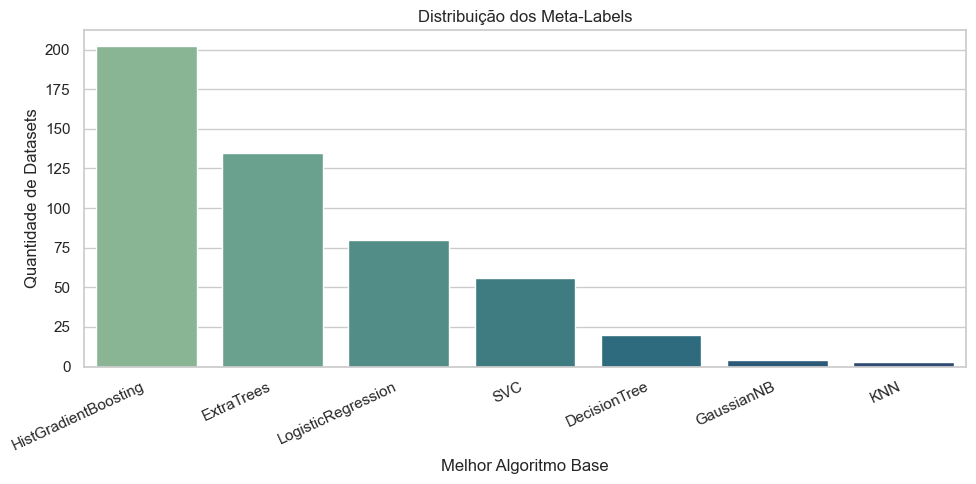

,meta_label,count
0,HistGradientBoosting,202
1,ExtraTrees,135
2,LogisticRegression,80
3,SVC,56
4,DecisionTree,20
5,GaussianNB,4
6,KNN,3




────────────────────────────────────────────────────────────────────────────────────────────────────




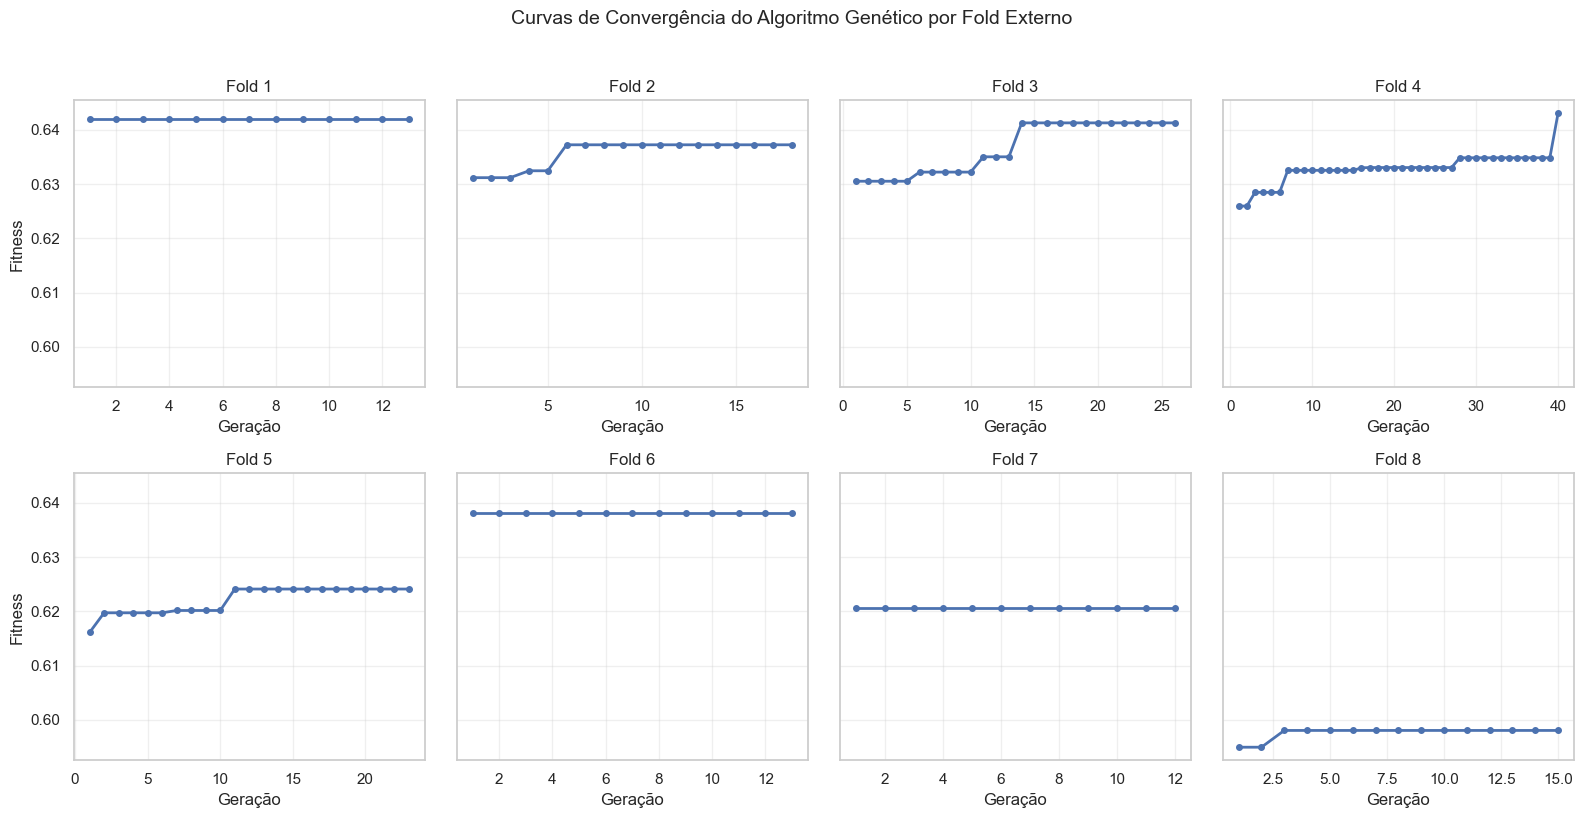

,Fold,Gerações,Fitness Inicial,Fitness Final,Melhoria Absoluta,Melhoria (%),Geração 95% Fitness Final,Desvio Fitness
0,1,13,0.642011,0.642011,0.000000,0.000000,1,1.110223e-16
1,2,18,0.631187,0.637246,0.006060,0.960019,1,2.507884e-03
2,3,26,0.630529,0.641286,0.010757,1.705992,1,4.693373e-03
3,4,40,0.625954,0.643038,0.017084,2.729279,1,2.848997e-03
4,5,23,0.616114,0.624115,0.008001,1.298655,1,2.392187e-03
5,6,13,0.638194,0.638194,0.000000,0.000000,1,0.000000e+00
6,7,12,0.620697,0.620697,0.000000,0.000000,1,1.110223e-16
7,8,15,0.594960,0.598051,0.003091,0.519530,1,1.050736e-03




────────────────────────────────────────────────────────────────────────────────────────────────────




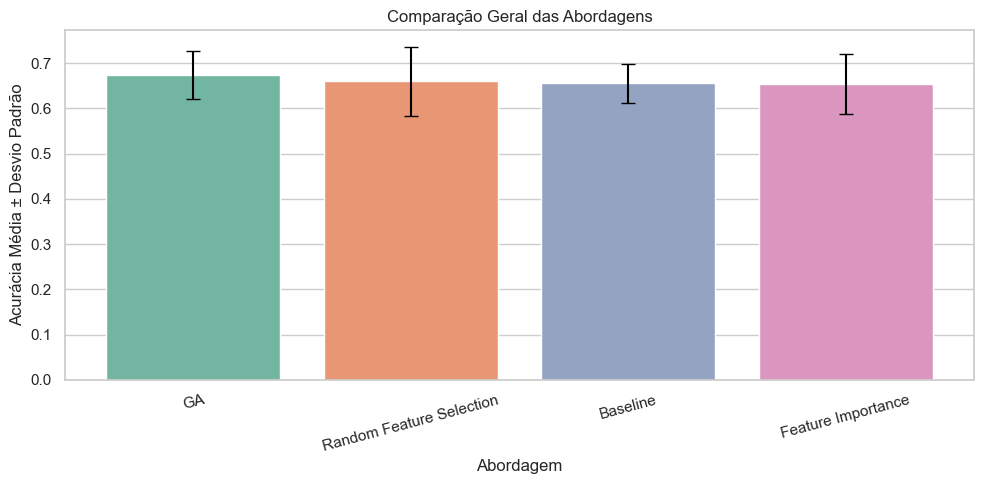

,Abordagem,Acurácia média no meta-teste,Desvio padrão
0,GA,0.674027,0.054125
1,Random Feature Selection,0.659946,0.076037
2,Baseline,0.655978,0.043139
3,Feature Importance,0.653994,0.067090




────────────────────────────────────────────────────────────────────────────────────────────────────




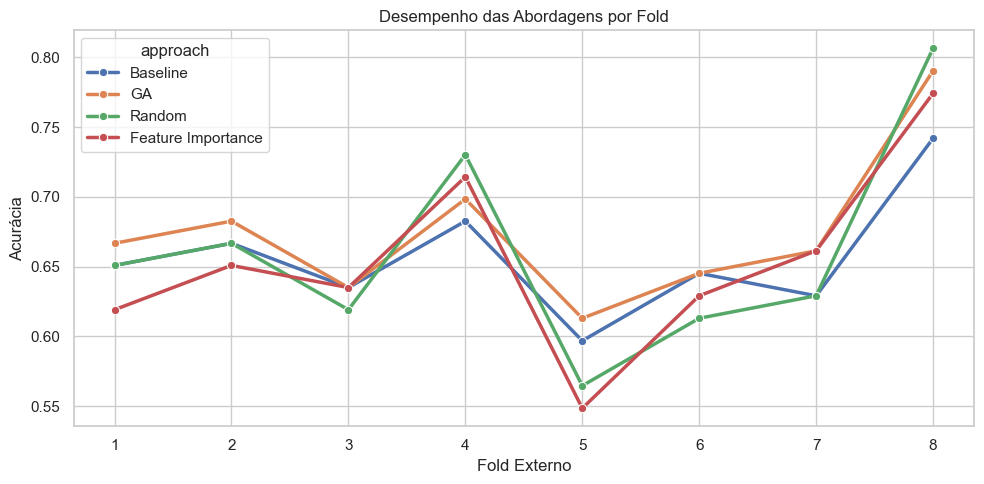

,fold,baseline_accuracy,ga_accuracy,random_accuracy,importance_accuracy
0,1,0.650794,0.666667,0.650794,0.619048
1,2,0.666667,0.682540,0.666667,0.650794
2,3,0.634921,0.634921,0.619048,0.634921
3,4,0.682540,0.698413,0.730159,0.714286
4,5,0.596774,0.612903,0.564516,0.548387
5,6,0.645161,0.645161,0.612903,0.629032
6,7,0.629032,0.661290,0.629032,0.661290
7,8,0.741935,0.790323,0.806452,0.774194




────────────────────────────────────────────────────────────────────────────────────────────────────


Redução média de dimensionalidade: 53.29%


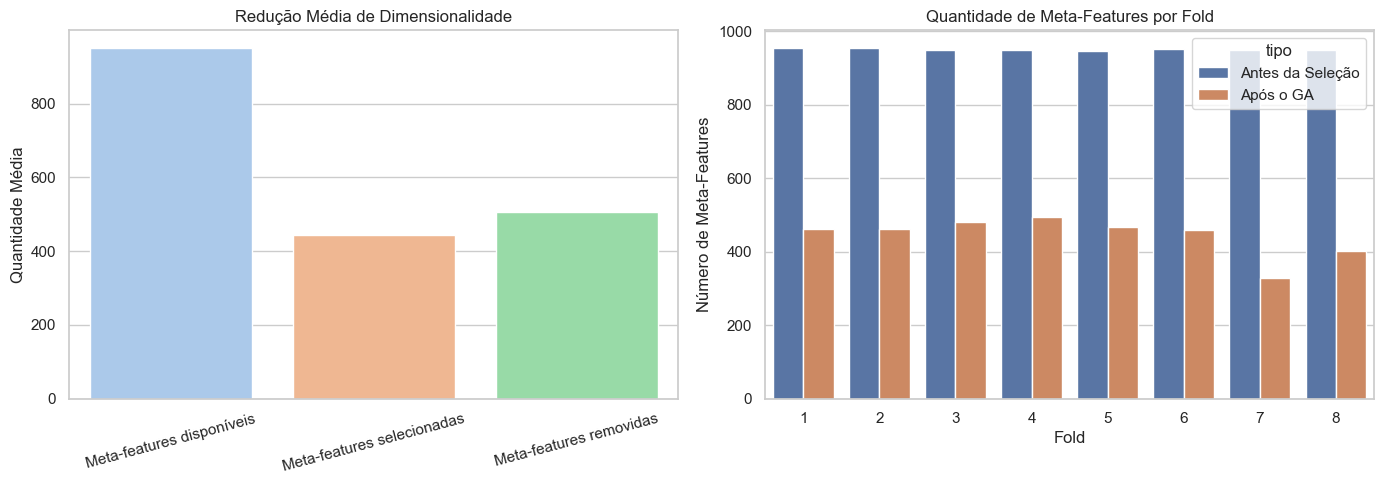

,fold,n_features_total,n_features_ga,reduction_pct
0,1,955,461,51.727749
1,2,954,462,51.572327
2,3,950,480,49.473684
3,4,950,494,48.000000
4,5,947,468,50.580781
5,6,953,458,51.941238
6,7,950,329,65.368421
7,8,950,402,57.684211




────────────────────────────────────────────────────────────────────────────────────────────────────




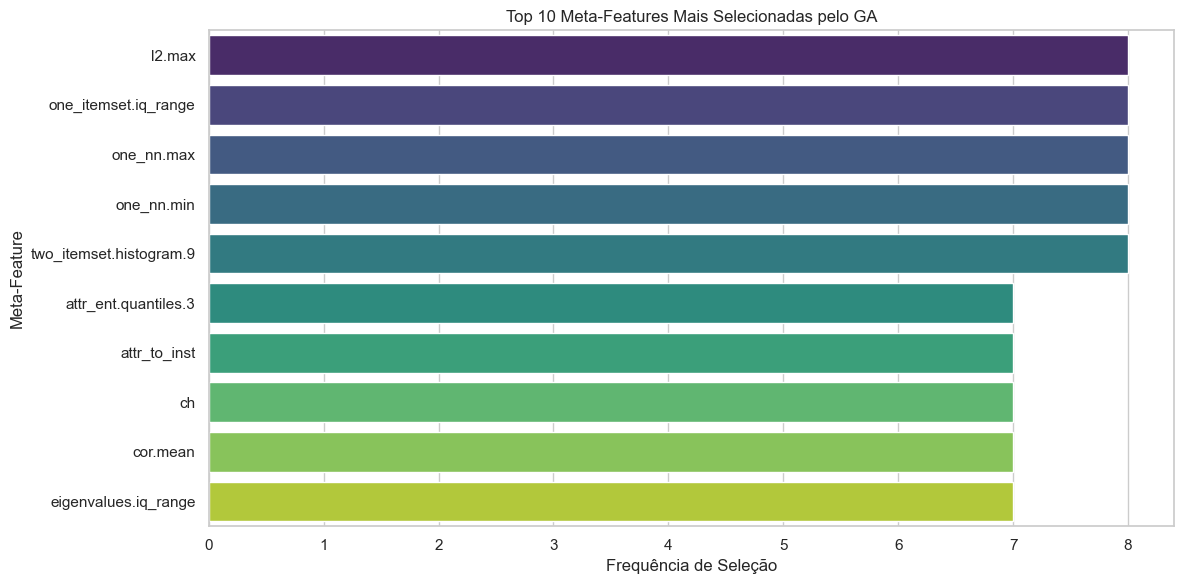

,meta_feature,frequencia
0,l2.max,8
1,one_itemset.iq_range,8
2,one_nn.max,8
3,one_nn.min,8
4,two_itemset.histogram.9,8
5,attr_ent.quantiles.3,7
6,attr_to_inst,7
7,ch,7
8,cor.mean,7
9,eigenvalues.iq_range,7


In [16]:
# ============================================================
# ANÁLISE VISUAL DOS RESULTADOS
# ============================================================
#
# Organização das visualizações:
#
# 1. Distribuição das meta-labels
# 2. Curvas de convergência do GA
# 3. Comparação geral entre abordagens
# 4. Desempenho por fold externo
# 5. Redução de dimensionalidade
# 6. Meta-features mais recorrentes
#
# ============================================================

# ============================================================
# 1. DISTRIBUIÇÃO DAS META-LABELS
# ============================================================

meta_label_counts = pd.Series(meta_y).value_counts().reset_index()
meta_label_counts.columns = ["meta_label", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=meta_label_counts,
    x="meta_label",
    y="count",
    palette="crest"
)

plt.title("Distribuição dos Meta-Labels")
plt.xlabel("Melhor Algoritmo Base")
plt.ylabel("Quantidade de Datasets")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(meta_label_counts)

print("\n")
print("─"*100)
print("\n")
# ============================================================
# 2. CURVAS DE CONVERGÊNCIA DO ALGORITMO GENÉTICO
# ============================================================

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8),
    sharey=True
)

axes = axes.flatten()

for fold_idx, history in enumerate(all_folds_ga_history, start=1):

    ax = axes[fold_idx - 1]

    ax.plot(
        np.arange(1, len(history) + 1),
        history,
        marker="o",
        linewidth=2,
        markersize=4
    )

    ax.set_title(f"Fold {fold_idx}")
    ax.set_xlabel("Geração")

    if fold_idx in [1, 5]:
        ax.set_ylabel("Fitness")

    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Curvas de Convergência do Algoritmo Genético por Fold Externo",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================

convergence_summary = []

for fold_idx, history in enumerate(all_folds_ga_history, start=1):

    target = history[-1] * 0.95

    generation_95 = next(
        (i + 1 for i, v in enumerate(history) if v >= target),
        len(history)
    )

    convergence_summary.append({
        "Fold": fold_idx,
        "Gerações": len(history),
        "Fitness Inicial": history[0],
        "Fitness Final": history[-1],
        "Melhoria Absoluta": history[-1] - history[0],
        "Melhoria (%)": 100 * (history[-1] - history[0]) / abs(history[0]),
        "Geração 95% Fitness Final": generation_95,
        "Desvio Fitness": np.std(history)
    })

convergence_summary_df = pd.DataFrame(convergence_summary)
display(convergence_summary_df)

print("\n")
print("─"*100)
print("\n")
# ============================================================
# 3. COMPARAÇÃO GERAL ENTRE AS ABORDAGENS
# ============================================================

plot_df = summary_table.copy()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="Abordagem",
    y="Acurácia média no meta-teste",
    palette="Set2"
)

plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["Acurácia média no meta-teste"],
    yerr=plot_df["Desvio padrão"],
    fmt="none",
    ecolor="black",
    capsize=5,
)

plt.title("Comparação Geral das Abordagens")
plt.xlabel("Abordagem")
plt.ylabel("Acurácia Média ± Desvio Padrão")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

display(summary_table)

print("\n")
print("─"*100)
print("\n")
# ============================================================
# 4. DESEMPENHO DAS ABORDAGENS AO LONGO DOS FOLDS
# ============================================================

performance_by_fold = results_df[
    [
        "fold",
        "baseline_accuracy",
        "ga_accuracy",
        "random_accuracy",
        "importance_accuracy"
    ]
].melt(
    id_vars="fold",
    var_name="approach",
    value_name="accuracy"
)

performance_by_fold["approach"] = performance_by_fold["approach"].map({
    "baseline_accuracy": "Baseline",
    "ga_accuracy": "GA",
    "random_accuracy": "Random",
    "importance_accuracy": "Feature Importance",
})

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=performance_by_fold,
    x="fold",
    y="accuracy",
    hue="approach",
    marker="o",
    linewidth=2.5
)

plt.title("Desempenho das Abordagens por Fold")
plt.xlabel("Fold Externo")
plt.ylabel("Acurácia")

plt.tight_layout()
plt.show()

display(
    results_df[
        [
            "fold",
            "baseline_accuracy",
            "ga_accuracy",
            "random_accuracy",
            "importance_accuracy"
        ]
    ]
)

print("\n")
print("─"*100)
print("\n")
# ============================================================
# 5. REDUÇÃO DE DIMENSIONALIDADE
# ============================================================

avg_total = results_df["n_features_total"].mean()
avg_ga = results_df["n_features_ga"].mean()
avg_removed = avg_total - avg_ga
avg_reduction = results_df["reduction_pct"].mean()

print(
    f"Redução média de dimensionalidade: "
    f"{avg_reduction:.2f}%"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_reduction = pd.DataFrame({
    "Categoria": [
        "Meta-features disponíveis",
        "Meta-features selecionadas",
        "Meta-features removidas"
    ],
    "Quantidade": [
        avg_total,
        avg_ga,
        avg_removed
    ]
})

sns.barplot(
    data=summary_reduction,
    x="Categoria",
    y="Quantidade",
    palette="pastel",
    ax=axes[0]
)

axes[0].set_title("Redução Média de Dimensionalidade")
axes[0].set_xlabel("")
axes[0].set_ylabel("Quantidade Média")
axes[0].tick_params(axis="x", rotation=15)

comparison_by_fold = pd.DataFrame({
    "fold": results_df["fold"].tolist() * 2,
    "tipo": (
        ["Antes da Seleção"] * len(results_df)
        + ["Após o GA"] * len(results_df)
    ),
    "n_features": (
        results_df["n_features_total"].tolist()
        + results_df["n_features_ga"].tolist()
    )
})

sns.barplot(
    data=comparison_by_fold,
    x="fold",
    y="n_features",
    hue="tipo",
    ax=axes[1]
)

axes[1].set_title("Quantidade de Meta-Features por Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Número de Meta-Features")

plt.tight_layout()
plt.show()

display(
    results_df[
        [
            "fold",
            "n_features_total",
            "n_features_ga",
            "reduction_pct"
        ]
    ]
)

print("\n")
print("─"*100)
print("\n")
# ============================================================
# 6. META-FEATURES MAIS RECORRENTES
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_features_df,
    x="frequencia",
    y="meta_feature",
    palette="viridis"
)

plt.title("Top 10 Meta-Features Mais Selecionadas pelo GA")
plt.xlabel("Frequência de Seleção")
plt.ylabel("Meta-Feature")

plt.tight_layout()
plt.show()

display(top_features_df)